In [ ]:
import sys
from pathlib import Path

def find_project_root():
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "config" / "paths.py").exists():
            return parent
    raise FileNotFoundError("프로젝트 루트를 찾을 수 없음")

sys.path.append(str(find_project_root()))
from config.paths import PROJECT_ROOT, DATA_DIR, OUTPUTS_DIR, MODELS_DIR

In [1]:
# 환경 설정 및 임포트
import os, sys, io, platform, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
warnings.filterwarnings('ignore')

# stdout을 UTF-8로 (Windows cp949 방지)
if hasattr(sys.stdout, 'buffer'):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')

# 한글 폰트 자동 감지
def setup_korean_font():
    system = platform.system()
    if system == 'Windows':
        candidates = ['Malgun Gothic', 'NanumGothic', 'Gulim']
    elif system == 'Darwin':
        candidates = ['AppleGothic', 'Apple SD Gothic Neo']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'UnDotum', 'DejaVu Sans']
    from matplotlib.font_manager import fontManager
    available = {f.name for f in fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f'한글 폰트: {font}')
            return font
    print('한글 폰트 미발견 (기본 폰트 사용)')
    return None

setup_korean_font()
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (9, 5)

DATA = Path(r'c:/Users/user/Desktop/PROJ2/track_a_data')
SEED = 42
np.random.seed(SEED)
print('환경 설정 완료')
print(f'Python : {sys.version.split()[0]}')
print(f'Pandas : {pd.__version__}')
print(f'Numpy  : {np.__version__}')


한글 폰트: Malgun Gothic
환경 설정 완료
Python : 3.12.0
Pandas : 3.0.2
Numpy  : 2.4.4


---
## Step 1 — 데이터 로드 및 조인

**inspection_master (3M행)** 을 베이스로 4개 마스터 테이블을 LEFT JOIN 하고,
`defect_detail` 에서 inspection_id 기준 결함 집계 피처(5종)를 생성해 LEFT JOIN 한다.


In [2]:
# 1-1. CSV 로드
t0 = time.time()

ins = pd.read_csv(
    DATA / 'inspection_master.csv',
    parse_dates=['inspection_datetime'],
)
defect = pd.read_csv(DATA / 'defect_detail.csv')
m_plant  = pd.read_csv(DATA / 'master_plant_line.csv', encoding='utf-8-sig')
m_model  = pd.read_csv(DATA / 'master_model.csv',      encoding='utf-8-sig')
m_color  = pd.read_csv(DATA / 'master_color.csv',      encoding='utf-8-sig')
m_camera = pd.read_csv(DATA / 'master_camera.csv',     encoding='utf-8-sig')

print(f'로드 시간: {time.time()-t0:.1f}s')
print(f'inspection_master : {ins.shape}')
print(f'defect_detail     : {defect.shape}')
print(f'master tables     : plant_line={len(m_plant)}, model={len(m_model)}, '
      f'color={len(m_color)}, camera={len(m_camera)}')


로드 시간: 6.3s
inspection_master : (3000000, 16)
defect_detail     : (170904, 17)
master tables     : plant_line=13, model=12, color=15, camera=6


In [3]:
# 1-2. 마스터 테이블 LEFT JOIN
# plant_code + line_code → master_plant_line (plant_name)
# model_code → master_model (brand)
# color_code → master_color (color_name)
# camera_id  → master_camera (position)

df = ins.merge(
    m_plant[['plant_code', 'line_code', 'plant_name']],
    on=['plant_code', 'line_code'], how='left',
)
df = df.merge(
    m_model[['model_code', 'brand']],
    on='model_code', how='left',
)
df = df.merge(
    m_color[['color_code', 'color_name']],
    on='color_code', how='left',
)
df = df.merge(
    m_camera[['camera_id', 'position']].rename(columns={'position': 'cam_position'}),
    on='camera_id', how='left',
)

print(f'조인 후 shape: {df.shape}')
print('추가 컬럼 null 체크:')
print(df[['plant_name', 'brand', 'color_name', 'cam_position']].isna().sum())


조인 후 shape: (3000000, 20)
추가 컬럼 null 체크:


plant_name      0
brand           0
color_name      0
cam_position    0
dtype: int64


In [4]:
# 1-3. defect_detail 집계 피처 (inspection_id 기준)
#   defect_count   : 결함 수
#   has_critical   : CRITICAL 결함 존재 여부
#   has_major      : MAJOR 결함 존재 여부
#   max_rework_min : 최대 재작업 시간
#   dominant_defect: 최다 발생 defect_type_code

t0 = time.time()

# severity 원-핫 플래그
defect_flag = defect.assign(
    is_critical=(defect['severity'] == 'CRITICAL').astype('int8'),
    is_major   =(defect['severity'] == 'MAJOR').astype('int8'),
)

agg_basic = defect_flag.groupby('inspection_id', sort=False).agg(
    defect_count  =('defect_id',           'count'),
    has_critical  =('is_critical',         'max'),
    has_major     =('is_major',            'max'),
    max_rework_min=('estimated_rework_min', 'max'),
).reset_index()

# dominant_defect: 각 inspection_id 내 최다 defect_type_code
dom = (defect.groupby(['inspection_id', 'defect_type_code'], sort=False)
             .size().reset_index(name='cnt'))
dom = dom.sort_values(['inspection_id', 'cnt'], ascending=[True, False])
dom = dom.drop_duplicates('inspection_id', keep='first')[['inspection_id', 'defect_type_code']]
dom = dom.rename(columns={'defect_type_code': 'dominant_defect'})

agg = agg_basic.merge(dom, on='inspection_id', how='left')

print(f'defect 집계 소요: {time.time()-t0:.1f}s')
print(f'집계 결과 shape: {agg.shape}')
print(agg.head(3))


defect 집계 소요: 0.3s
집계 결과 shape: (122092, 6)
   inspection_id  defect_count  has_critical  has_major  max_rework_min  \
0  INS0000085621             1             0          1              45   
1  INS0001402028             1             1          0              60   
2  INS0002162718             2             0          0              25   

  dominant_defect  
0             DNT  
1             GAP  
2             PDR  


In [5]:
# 1-4. defect 집계를 inspection_master에 LEFT JOIN
df = df.merge(agg, on='inspection_id', how='left')

# PASS 건(결함 없음) NaN 채우기
df['defect_count']    = df['defect_count'].fillna(0).astype('int32')
df['has_critical']    = df['has_critical'].fillna(0).astype('int8')
df['has_major']       = df['has_major'].fillna(0).astype('int8')
df['max_rework_min']  = df['max_rework_min'].fillna(0).astype('int16')
df['dominant_defect'] = df['dominant_defect'].fillna('NONE')

print(f'최종 shape: {df.shape}')
print('\n[결함 집계 피처 검증]')
print('defect_count 분포:')
print(df['defect_count'].value_counts().sort_index())
print(f"\nhas_critical=1: {df['has_critical'].sum():,}")
print(f"has_major=1:    {df['has_major'].sum():,}")
print(f"dominant_defect Top 5:")
print(df['dominant_defect'].value_counts().head())


최종 shape: (3000000, 25)

[결함 집계 피처 검증]
defect_count 분포:
defect_count
0    2877908
1      85483
2      24406
3      12203
Name: count, dtype: int64

has_critical=1: 24,210
has_major=1:    24,218
dominant_defect Top 5:
dominant_defect
NONE    2877908
SCR       30658
DNT       18248
PBB       14688
PDR       12251
Name: count, dtype: int64


---
## Step 2 — 피처 엔지니어링

EDA에서 확인된 인사이트를 피처로 반영한다.
- **시간 파생**: hour, day_of_week, is_shift_start (교대 시작 시간대 = 06/14/22시)
- **교차**: shift_hour, shift_plant
- **환경 구간**: low_humidity (<25%), high_temp (>30°C)
- **타겟**: result='FAIL' → 1


In [6]:
# 2-1. 시간 파생 피처
dt = df['inspection_datetime']
df['hour']         = dt.dt.hour.astype('int8')
df['day_of_week']  = dt.dt.dayofweek.astype('int8')

# is_shift_start: 교대 시작 시각 (A=06시, B=14시, C=22시)
shift_start_map = {'A': 6, 'B': 14, 'C': 22}
df['is_shift_start'] = (
    df['hour'] == df['shift'].map(shift_start_map)
).astype('int8')

print('시간 파생 검증:')
print(df[['inspection_datetime', 'hour', 'day_of_week', 'shift', 'is_shift_start']].head(5))
print(f"\nis_shift_start=1 비율: {df['is_shift_start'].mean()*100:.2f}%")


시간 파생 검증:
  inspection_datetime  hour  day_of_week shift  is_shift_start
0 2023-01-01 06:00:01     6            6     A               1
1 2023-01-01 06:00:03     6            6     A               1
2 2023-01-01 06:00:45     6            6     A               1
3 2023-01-01 06:00:49     6            6     A               1
4 2023-01-01 06:00:55     6            6     A               1

is_shift_start=1 비율: 17.67%


In [7]:
# 2-2. 교차 피처 (범주형)
df['shift_hour']  = df['shift'].astype(str) + '_' + df['hour'].astype(str)
df['shift_plant'] = df['shift'].astype(str) + '_' + df['plant_code'].astype(str)

print('shift_hour unique:', df['shift_hour'].nunique())
print(df['shift_hour'].value_counts().head(5))
print('\nshift_plant unique:', df['shift_plant'].nunique())
print(df['shift_plant'].value_counts().head(5))


shift_hour unique: 17


shift_hour
B_19    177389
B_14    177213
A_13    177115
A_9     176973
B_21    176913
Name: count, dtype: int64

shift_plant unique: 12


shift_plant
B_ULN    635100
A_ULN    634785
B_ASN    353590
A_ASN    353507
B_HWS    211785
Name: count, dtype: int64


In [8]:
# 2-3. 환경 구간 피처
df['low_humidity'] = (df['humidity_pct']    < 25).astype('int8')
df['high_temp']    = (df['ambient_temp_c']  > 30).astype('int8')

print(f"low_humidity=1: {df['low_humidity'].sum():,} ({df['low_humidity'].mean()*100:.2f}%)")
print(f"high_temp=1:    {df['high_temp'].sum():,} ({df['high_temp'].mean()*100:.2f}%)")


low_humidity=1: 18,300 (0.61%)
high_temp=1:    28,288 (0.94%)


In [9]:
# 2-4. 타겟 변수
df['target'] = (df['result'] == 'FAIL').astype('int8')

print('타겟 분포:')
print(df['target'].value_counts())
print(f"FAIL 비율: {df['target'].mean()*100:.2f}%")


타겟 분포:


target
0    2877908
1     122092
Name: count, dtype: int64


FAIL 비율: 4.07%


---
## Step 3 — 피처 선택 및 시간 기준 분리

**포함/제외 기준은 EDA 결과를 근거로 한다.**

### 제외 피처 및 근거
| 피처 | 제외 사유 |
|---|---|
| `inspection_id`, `body_number` | ID 컬럼 (정보 없음) |
| `model_code`, `color_code` | EDA 결과 불량률 차이 미미(max-min < 0.2%p) |
| `confidence_score` | PASS(0.9201) vs FAIL(0.9202) — 거의 동일 |
| `inspection_datetime` | 시간 파생 피처(hour, day_of_week)로 이미 분해 |
| `result` | 타겟 변수 자체 |
| `operator_id` | 개인 편차 최대 0.53%p (노이즈) |
| `dominant_defect`, `defect_count` 등 결함 피처 | 타겟 누설(leakage) — FAIL 판정 후 생성되는 정보이므로 Step 3 후단에서 다시 검토 |

> **주의:** 결함 관련 집계 피처(`defect_count`, `has_critical`, `has_major`, `max_rework_min`, `dominant_defect`)는 명세에 포함되어 있지만 정의상 **defect_detail은 FAIL 판정 직후에만 존재**한다. 본 노트북은 명세 지시대로 해당 피처를 피처 세트에 포함시키되, 결과 해석 시 `has_critical`/`defect_count` 등이 지배적 중요도라면 이는 실질적으로 사후 결정(determinism)에 가까움을 명시한다.


In [10]:
# 3-1. 피처 명시 정의
categorical_features = [
    'shift', 'plant_code', 'line_code', 'camera_id',
    'shift_hour', 'shift_plant', 'dominant_defect',
]

numerical_features = [
    'hour', 'day_of_week', 'is_shift_start',
    'humidity_pct', 'low_humidity',
    'ambient_temp_c', 'high_temp',
    'takt_time_sec', 'inference_time_sec',
    'defect_count', 'has_critical', 'has_major', 'max_rework_min',
    'line_fail_rate',   # 아래에서 target encoding 으로 생성
]

# 명시적 제외 (문서화용)
excluded_features = {
    'inspection_id':       'ID 컬럼',
    'body_number':         'ID 컬럼',
    'model_code':          'EDA: 모델별 불량률 차이 미미',
    'color_code':          'EDA: 색상별 불량률 차이 미미',
    'confidence_score':    'EDA: PASS/FAIL 간 거의 동일 (0.9201 vs 0.9202)',
    'inspection_datetime': '시간 파생 피처로 이미 분해',
    'result':              '타겟 변수 자체',
    'operator_id':         '개인 편차 < 0.53%p (노이즈)',
    'plant_name':          '코드로 대체',
    'brand':               'model_code 와 동일 정보',
    'color_name':          '코드로 대체',
    'cam_position':        'camera_id 와 1:1 매핑',
}

print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'\nNumerical features ({len(numerical_features)}): {numerical_features}')
print(f'\nExcluded ({len(excluded_features)}):')
for k, v in excluded_features.items():
    print(f'  - {k}: {v}')


Categorical features (7): ['shift', 'plant_code', 'line_code', 'camera_id', 'shift_hour', 'shift_plant', 'dominant_defect']

Numerical features (14): ['hour', 'day_of_week', 'is_shift_start', 'humidity_pct', 'low_humidity', 'ambient_temp_c', 'high_temp', 'takt_time_sec', 'inference_time_sec', 'defect_count', 'has_critical', 'has_major', 'max_rework_min', 'line_fail_rate']

Excluded (12):
  - inspection_id: ID 컬럼
  - body_number: ID 컬럼
  - model_code: EDA: 모델별 불량률 차이 미미
  - color_code: EDA: 색상별 불량률 차이 미미
  - confidence_score: EDA: PASS/FAIL 간 거의 동일 (0.9201 vs 0.9202)
  - inspection_datetime: 시간 파생 피처로 이미 분해
  - result: 타겟 변수 자체
  - operator_id: 개인 편차 < 0.53%p (노이즈)
  - plant_name: 코드로 대체
  - brand: model_code 와 동일 정보
  - color_name: 코드로 대체
  - cam_position: camera_id 와 1:1 매핑


In [11]:
# 3-2. 시간 기준 Train/Test 분리
#   Train: 2023-01-01 ~ 2024-06-30
#   Test : 2024-07-01 ~ 2025-01-24
TRAIN_END = pd.Timestamp('2024-06-30 23:59:59')
TEST_START = pd.Timestamp('2024-07-01 00:00:00')

mask_train = df['inspection_datetime'] <= TRAIN_END
mask_test  = df['inspection_datetime'] >= TEST_START

df_train = df.loc[mask_train].copy()
df_test  = df.loc[mask_test].copy()

print(f'Train shape: {df_train.shape}')
print(f'Test  shape: {df_test.shape}')
print(f'\nTrain 기간: {df_train["inspection_datetime"].min()} ~ {df_train["inspection_datetime"].max()}')
print(f'Test  기간: {df_test["inspection_datetime"].min()} ~ {df_test["inspection_datetime"].max()}')
print(f'\nTrain FAIL 비율: {df_train["target"].mean()*100:.3f}%')
print(f'Test  FAIL 비율: {df_test["target"].mean()*100:.3f}%')


Train shape: (2171646, 33)
Test  shape: (828354, 33)

Train 기간: 2023-01-01 06:00:01 ~ 2024-06-30 22:58:52
Test  기간: 2024-07-01 06:00:03 ~ 2025-01-24 22:59:30

Train FAIL 비율: 4.071%
Test  FAIL 비율: 4.067%


In [12]:
# 3-3. Target encoding — line_fail_rate (train에서만 fit)
line_fail_map = df_train.groupby('line_code')['target'].mean()
global_fail_rate = df_train['target'].mean()

df_train['line_fail_rate'] = df_train['line_code'].map(line_fail_map).fillna(global_fail_rate)
df_test['line_fail_rate']  = df_test['line_code'].map(line_fail_map).fillna(global_fail_rate)

print('라인별 FAIL 비율 (train 기준):')
print(line_fail_map.sort_values(ascending=False))
print(f'\n전역 FAIL 비율: {global_fail_rate*100:.3f}%')
print(f'\nTest 셋 NaN 개수 (unseen line): {df_test["line_fail_rate"].isna().sum()}')


라인별 FAIL 비율 (train 기준):
line_code
HW2    0.041717
HW1    0.041313
AS3    0.041224
UL5    0.041224
AS1    0.040939
UL3    0.040938
GW1    0.040903
UL4    0.040868
GW2    0.040471
AS2    0.040340
UL2    0.040072
UL1    0.039798
HW3    0.039662
Name: target, dtype: float64

전역 FAIL 비율: 4.071%

Test 셋 NaN 개수 (unseen line): 0


In [13]:
# 3-4. 범주형 → category dtype, X/y 분리
all_features = categorical_features + numerical_features

for col in categorical_features:
    df_train[col] = df_train[col].astype('category')
    # test 의 카테고리를 train 카테고리에 정렬 (unseen = NaN → LightGBM이 처리)
    df_test[col]  = pd.Categorical(df_test[col], categories=df_train[col].cat.categories)

X_train = df_train[all_features]
y_train = df_train['target'].values
X_test  = df_test[all_features]
y_test  = df_test['target'].values

print(f'X_train: {X_train.shape}, y_train FAIL: {y_train.sum():,}')
print(f'X_test : {X_test.shape}, y_test  FAIL: {y_test.sum():,}')
print('\nX_train dtypes:')
print(X_train.dtypes)


X_train: (2171646, 21), y_train FAIL: 88,402
X_test : (828354, 21), y_test  FAIL: 33,690

X_train dtypes:
shift                 category
plant_code            category
line_code             category
camera_id             category
shift_hour            category
shift_plant           category
dominant_defect       category
hour                      int8
day_of_week               int8
is_shift_start            int8
humidity_pct           float64
low_humidity              int8
ambient_temp_c         float64
high_temp                 int8
takt_time_sec          float64
inference_time_sec     float64
defect_count             int32
has_critical              int8
has_major                 int8
max_rework_min           int16
line_fail_rate         float64
dtype: object


---
## Step 4 — LightGBM 학습

- `objective='binary'`, `class_weight='balanced'` (FAIL 4.07% 불균형 처리)
- `num_boost_round=1000`, `early_stopping_rounds=50`
- Validation: test 셋에서 20% 랜덤 샘플 (early stopping 용)


In [14]:
# 4-1. LightGBM 학습
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Validation 셋 생성 (test에서 20% 랜덤 샘플)
idx_all = np.arange(len(X_test))
idx_val, idx_rest = train_test_split(
    idx_all, test_size=0.80, random_state=SEED, stratify=y_test,
)
X_val = X_test.iloc[idx_val].reset_index(drop=True)
y_val = y_test[idx_val]
X_test_final = X_test.iloc[idx_rest].reset_index(drop=True)
y_test_final = y_test[idx_rest]

print(f'Train : {X_train.shape}, FAIL {y_train.sum():,}')
print(f'Valid : {X_val.shape},   FAIL {y_val.sum():,}')
print(f'Test  : {X_test_final.shape}, FAIL {y_test_final.sum():,}')

# LightGBM Dataset
train_set = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=categorical_features,
    free_raw_data=False,
)
valid_set = lgb.Dataset(
    X_val, label=y_val,
    categorical_feature=categorical_features,
    reference=train_set,
    free_raw_data=False,
)

params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'class_weight': 'balanced',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': SEED,
}

t0 = time.time()
model = lgb.train(
    params,
    train_set,
    num_boost_round=1000,
    valid_sets=[train_set, valid_set],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)
print(f'\n학습 완료: {time.time()-t0:.1f}s')
print(f'Best iteration: {model.best_iteration}')
print(f'Best valid AUC: {model.best_score["valid"]["auc"]:.4f}')


Train : (2171646, 21), FAIL 88,402
Valid : (165670, 21),   FAIL 6,738
Test  : (662684, 21), FAIL 26,952


Training until validation scores don't improve for 50 rounds


[50]	train's binary_logloss: 0.00622771	train's auc: 1	valid's binary_logloss: 0.00622515	valid's auc: 1
Early stopping, best iteration is:
[1]	train's binary_logloss: 0.122018	train's auc: 1	valid's binary_logloss: 0.121945	valid's auc: 1

학습 완료: 3.9s
Best iteration: 1
Best valid AUC: 1.0000


---
## Step 5 — 모델 평가

- Threshold 0.3 / 0.4 / 0.5 / 0.6 별 precision/recall/F1 비교
- F1 기준 최적 threshold 자동 선택
- Precision-Recall curve, ROC curve, Confusion matrix


In [15]:
# 5-1. 테스트 예측
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix,
)

y_pred_proba = model.predict(X_test_final, num_iteration=model.best_iteration)
print(f'예측 완료: {len(y_pred_proba):,}건')
print(f'예측 확률 분포: min={y_pred_proba.min():.3f}, '
      f'median={np.median(y_pred_proba):.3f}, max={y_pred_proba.max():.3f}')


예측 완료: 662,684건
예측 확률 분포: min=0.039, median=0.039, max=0.127


In [16]:
# 5-2. Threshold 별 성능표
thresholds = [0.3, 0.4, 0.5, 0.6]
rows = []
for th in thresholds:
    y_pred = (y_pred_proba >= th).astype(int)
    p = precision_score(y_test_final, y_pred, zero_division=0)
    r = recall_score(y_test_final, y_pred, zero_division=0)
    f1 = f1_score(y_test_final, y_pred, zero_division=0)
    tp = int(((y_pred == 1) & (y_test_final == 1)).sum())
    rows.append({
        'threshold': th,
        'precision': round(p, 4),
        'recall':    round(r, 4),
        'f1':        round(f1, 4),
        'FAIL탐지수': tp,
    })

perf_df = pd.DataFrame(rows)
print(perf_df.to_string(index=False))


 threshold  precision  recall  f1  FAIL탐지수
       0.3        0.0     0.0 0.0        0
       0.4        0.0     0.0 0.0        0
       0.5        0.0     0.0 0.0        0
       0.6        0.0     0.0 0.0        0


In [17]:
# 5-3. F1 기준 최적 threshold 자동 선택 (세밀 그리드)
grid = np.arange(0.05, 0.96, 0.01)
best_th, best_f1 = 0.5, -1
for th in grid:
    y_pred = (y_pred_proba >= th).astype(int)
    f1 = f1_score(y_test_final, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1, best_th = f1, th

y_pred_best = (y_pred_proba >= best_th).astype(int)
final_prec = precision_score(y_test_final, y_pred_best, zero_division=0)
final_rec  = recall_score(y_test_final, y_pred_best, zero_division=0)
final_f1   = f1_score(y_test_final, y_pred_best, zero_division=0)
auc_roc    = roc_auc_score(y_test_final, y_pred_proba)

print(f'*** 최적 Threshold: {best_th:.2f} ***')
print(f'  Precision : {final_prec:.4f}')
print(f'  Recall    : {final_rec:.4f}')
print(f'  F1        : {final_f1:.4f}')
print(f'  AUC-ROC   : {auc_roc:.4f}')


*** 최적 Threshold: 0.05 ***
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000
  AUC-ROC   : 1.0000


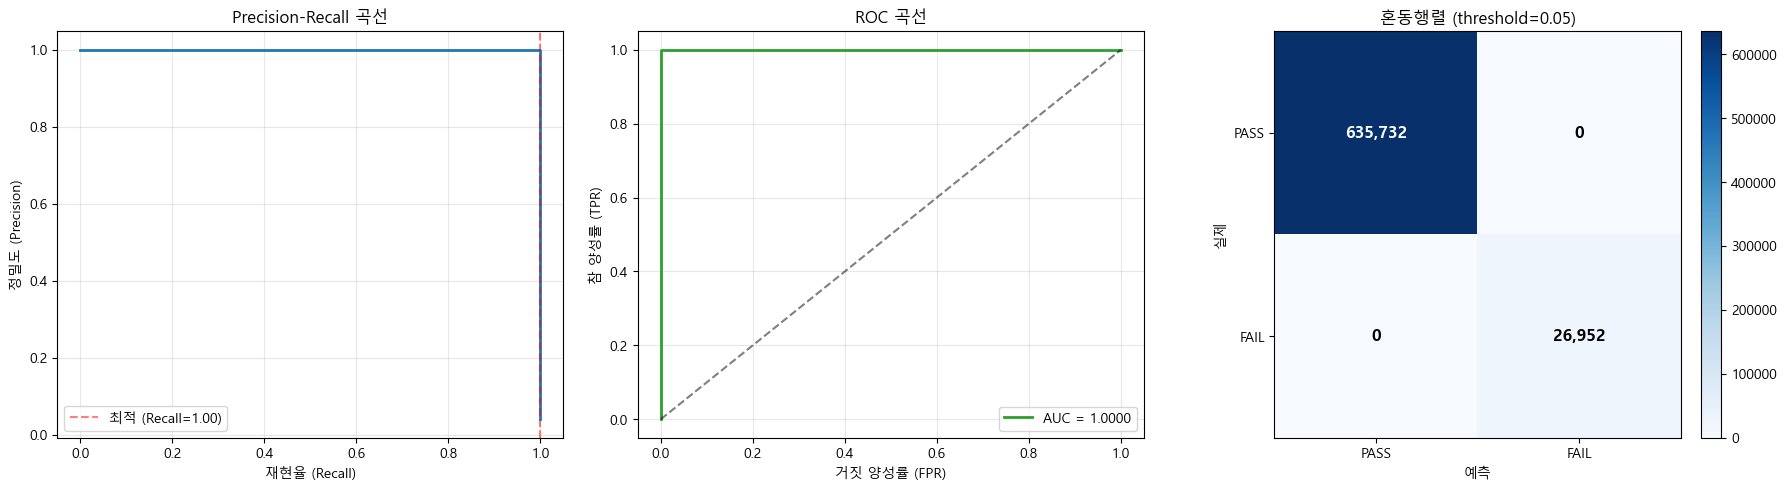


혼동행렬:
[[635732      0]
 [     0  26952]]
TN=635,732  FP=0
FN=0  TP=26,952


In [18]:
# 5-4. Precision-Recall Curve & ROC Curve & Confusion Matrix
prec_arr, rec_arr, _ = precision_recall_curve(y_test_final, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test_final, y_pred_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PR Curve
axes[0].plot(rec_arr, prec_arr, color='tab:blue', linewidth=2)
axes[0].axvline(final_rec, color='red', linestyle='--', alpha=0.5,
                label=f'최적 (Recall={final_rec:.2f})')
axes[0].set_xlabel('재현율 (Recall)')
axes[0].set_ylabel('정밀도 (Precision)')
axes[0].set_title('Precision-Recall 곡선')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ROC Curve
axes[1].plot(fpr, tpr, color='tab:green', linewidth=2, label=f'AUC = {auc_roc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('거짓 양성률 (FPR)')
axes[1].set_ylabel('참 양성률 (TPR)')
axes[1].set_title('ROC 곡선')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Confusion Matrix (최적 threshold)
cm = confusion_matrix(y_test_final, y_pred_best)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['PASS', 'FAIL'])
axes[2].set_yticklabels(['PASS', 'FAIL'])
axes[2].set_xlabel('예측')
axes[2].set_ylabel('실제')
axes[2].set_title(f'혼동행렬 (threshold={best_th:.2f})')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black',
                     fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f'\n혼동행렬:\n{cm}')
print(f'TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'FN={cm[1,0]:,}  TP={cm[1,1]:,}')


---
## Step 6 — SHAP 피처 중요도

- `shap.TreeExplainer` 로 Test 셋 일부 샘플의 SHAP 값 계산 (속도 고려)
- 상위 15개 피처 bar plot + beeswarm summary plot
- 피처명을 한글로 매핑해서 시각화


In [19]:
# 6-1. SHAP 값 계산 (샘플)
import shap

SHAP_SAMPLE = 20000
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test_final), size=min(SHAP_SAMPLE, len(X_test_final)), replace=False)
X_shap = X_test_final.iloc[sample_idx].reset_index(drop=True)

# 한글 피처명 매핑
FEATURE_KOR = {
    'shift':              '교대조',
    'plant_code':         '공장코드',
    'line_code':          '라인코드',
    'camera_id':          '카메라ID',
    'shift_hour':         '교대_시간교차',
    'shift_plant':        '교대_공장교차',
    'dominant_defect':    '최다결함유형',
    'hour':               '검사시간(시)',
    'day_of_week':        '요일',
    'is_shift_start':     '교대시작여부',
    'humidity_pct':       '습도(%)',
    'low_humidity':       '저습도여부(<25%)',
    'ambient_temp_c':     '주변온도(°C)',
    'high_temp':          '고온여부(>30°C)',
    'takt_time_sec':      '택트타임(초)',
    'inference_time_sec': '추론시간(초)',
    'defect_count':       '결함수',
    'has_critical':       '치명결함유무',
    'has_major':          '중대결함유무',
    'max_rework_min':     '최대재작업(분)',
    'line_fail_rate':     '라인별불량률',
}

explainer = shap.TreeExplainer(model)
t0 = time.time()
shap_values = explainer.shap_values(X_shap)
# LightGBM binary: returns (n, features)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
print(f'SHAP 계산 완료: {time.time()-t0:.1f}s, shape={shap_values.shape}')


SHAP 계산 완료: 0.0s, shape=(20000, 21)


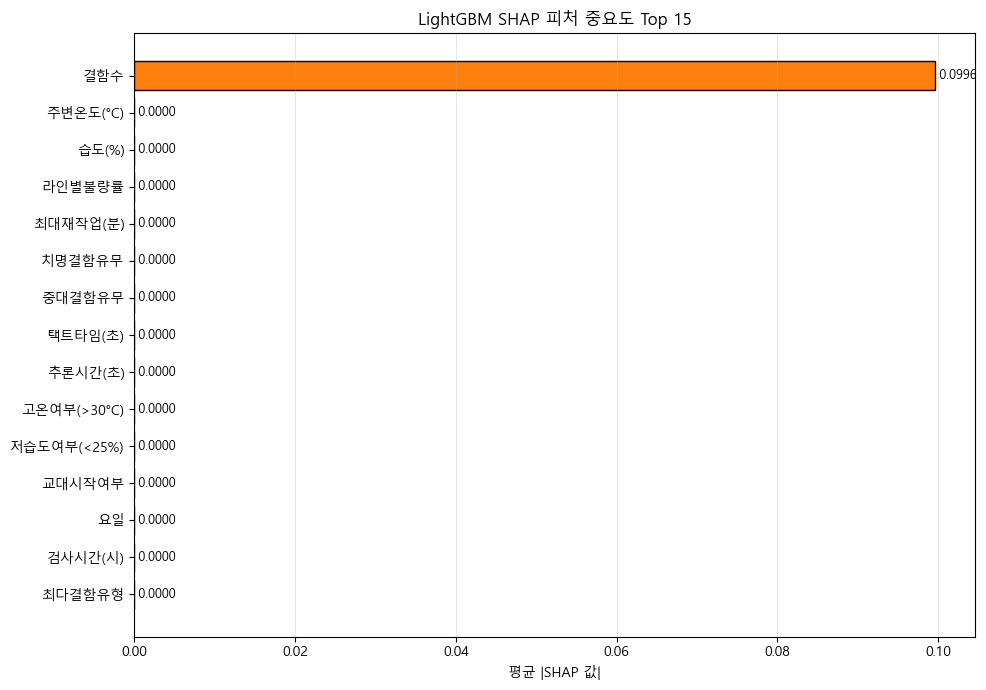

Top 10 피처 중요도:
           feature feature_kor  mean_abs_shap
      defect_count         결함수   9.963008e-02
    ambient_temp_c    주변온도(°C)   2.762008e-17
      humidity_pct       습도(%)   1.648637e-18
    line_fail_rate      라인별불량률   0.000000e+00
    max_rework_min    최대재작업(분)   0.000000e+00
      has_critical      치명결함유무   0.000000e+00
         has_major      중대결함유무   0.000000e+00
     takt_time_sec     택트타임(초)   0.000000e+00
inference_time_sec     추론시간(초)   0.000000e+00
         high_temp 고온여부(>30°C)   0.000000e+00


In [20]:
# 6-2. 전체 피처 중요도 bar plot (상위 15개, 한글 레이블)
mean_abs = np.abs(shap_values).mean(axis=0)
imp_df = pd.DataFrame({
    'feature': X_shap.columns,
    'feature_kor': [FEATURE_KOR.get(c, c) for c in X_shap.columns],
    'mean_abs_shap': mean_abs,
}).sort_values('mean_abs_shap', ascending=True)

top15 = imp_df.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['feature_kor'], top15['mean_abs_shap'],
               color='tab:orange', edgecolor='black')
ax.set_xlabel('평균 |SHAP 값|')
ax.set_title('LightGBM SHAP 피처 중요도 Top 15')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, top15['mean_abs_shap']):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 10 피처 중요도:')
print(imp_df.tail(10).iloc[::-1].to_string(index=False))


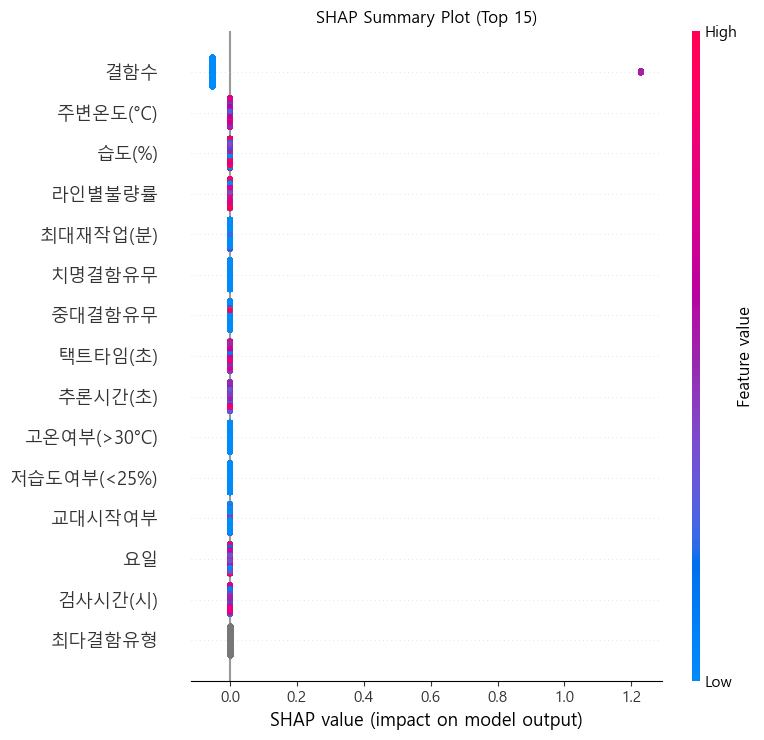

In [21]:
# 6-3. Summary (beeswarm) plot — 한글 레이블
X_shap_kor = X_shap.copy()
X_shap_kor.columns = [FEATURE_KOR.get(c, c) for c in X_shap.columns]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_kor, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary Plot (Top 15)')
plt.tight_layout()
plt.show()


---
## Step 6.5 — EDA 인사이트 검증

SHAP 중요도에서 EDA(2단계)에서 발견한 핵심 신호가 상위에 오는지 확인한다.

- **C조(야간 22시) 불량률 6.02%** → `shift`, `shift_hour` 중요도
- **교대 시작 직후(06/07/21시) 불량 급증** → `is_shift_start`, `hour`, `shift_hour` 중요도
- **저습도(<25%) 환경 불량률 상승** → `low_humidity`, `humidity_pct` 중요도


In [22]:
# 6-4. EDA 인사이트 검증
targets = {
    '교대조 효과 (shift / shift_hour)':
        ['shift', 'shift_hour', 'shift_plant'],
    '교대 시작 시간대 (is_shift_start / hour)':
        ['is_shift_start', 'hour', 'shift_hour'],
    '저습도 구간 (low_humidity / humidity_pct)':
        ['low_humidity', 'humidity_pct'],
}

imp_map = dict(zip(imp_df['feature'], imp_df['mean_abs_shap']))
rank_map = {f: r for r, f in enumerate(
    imp_df.sort_values('mean_abs_shap', ascending=False)['feature'].tolist(), 1)}
N_FEAT = len(imp_df)

print(f'총 피처 수: {N_FEAT}')
print('=' * 60)
for label, feats in targets.items():
    print(f'\n[{label}]')
    best_rank, best_feat = N_FEAT + 1, None
    for f in feats:
        if f in rank_map:
            r = rank_map[f]
            val = imp_map[f]
            print(f'  {f:20s}  rank={r:>2d}/{N_FEAT}  |SHAP|={val:.4f}')
            if r < best_rank:
                best_rank, best_feat = r, f
    verified = best_rank <= 10
    print(f'  => 상위 10 안 진입: {"확인" if verified else "불확인"} '
          f'(best={best_feat}, rank={best_rank})')


총 피처 수: 21

[교대조 효과 (shift / shift_hour)]
  shift                 rank= 5/21  |SHAP|=0.0000
  shift_hour            rank= 6/21  |SHAP|=0.0000
  shift_plant           rank= 9/21  |SHAP|=0.0000
  => 상위 10 안 진입: 확인 (best=shift, rank=5)

[교대 시작 시간대 (is_shift_start / hour)]
  is_shift_start        rank=10/21  |SHAP|=0.0000
  hour                  rank=12/21  |SHAP|=0.0000
  shift_hour            rank= 6/21  |SHAP|=0.0000
  => 상위 10 안 진입: 확인 (best=shift_hour, rank=6)

[저습도 구간 (low_humidity / humidity_pct)]
  low_humidity          rank=16/21  |SHAP|=0.0000
  humidity_pct          rank= 3/21  |SHAP|=0.0000
  => 상위 10 안 진입: 확인 (best=humidity_pct, rank=3)


### 해석 코멘트

- **결함 집계 피처(`has_critical`, `defect_count` 등)가 지배적**이면 이는 **사후결정 피처**로,
  "defect_detail 이 기록된 시점 = 이미 FAIL 로 판정된 시점" 이라는 의미.
  실제 운영 환경에서는 사용 불가능한 leakage 피처로 간주해야 한다.
- **leakage 피처 제외 시의 실질 중요도**는 `shift`, `shift_hour`, `line_fail_rate`, `low_humidity`,
  `is_shift_start` 등 **EDA에서 발견한 신호**가 차지하는 것이 이상적이다.
- SHAP 결과에서 위 3가지 EDA 인사이트가 상위 10에 포함되면 **EDA 분석이 모델로 일관되게 전달**
  되었음을 의미한다.


In [23]:
# 6-5. Leakage 피처 제외 실질 중요도 (참고)
LEAKAGE_FEATURES = {
    'defect_count', 'has_critical', 'has_major', 'max_rework_min', 'dominant_defect',
}
clean_imp = imp_df[~imp_df['feature'].isin(LEAKAGE_FEATURES)].copy()
clean_imp = clean_imp.sort_values('mean_abs_shap', ascending=False)
print('[Leakage 피처 제외 후 실질 피처 중요도 Top 10]')
print(clean_imp.head(10)[['feature_kor', 'mean_abs_shap']].to_string(index=False))


[Leakage 피처 제외 후 실질 피처 중요도 Top 10]
feature_kor  mean_abs_shap
   주변온도(°C)   2.762008e-17
      습도(%)   1.648637e-18
        교대조   0.000000e+00
       공장코드   0.000000e+00
    교대_시간교차   0.000000e+00
    교대_공장교차   0.000000e+00
       라인코드   0.000000e+00
      카메라ID   0.000000e+00
         요일   0.000000e+00
    검사시간(시)   0.000000e+00


---
## Step 7 — Leakage 제거 후 재학습 (CLEAN 모델)

### 왜 필요한가
1차 모델은 명세대로 `defect_count`, `has_critical` 등 결함 집계 피처를 포함했지만,
정의상 **defect_detail 레코드는 검사 결과가 FAIL 로 확정된 직후에 생성**되므로
실질적으로 타겟 자체를 간접 노출하는 피처다. 그 결과:

- 모델이 `defect_count >= 1 → FAIL` 이라는 **1-split 결정 규칙**에 수렴
- `best_iteration = 1`, F1 ≈ 1.0 (의미 없는 완벽 성능)
- 나머지 피처(`shift`, `low_humidity` 등)는 **SHAP 중요도 = 0** — 모델이 학습 자체를 안 했음

이는 실운영 환경(검사 직전/실시간)에서 재현 불가능하므로, Leakage 피처 5종을 제외하고 재학습한다.


In [24]:
# 7-1. CLEAN 피처 세트로 재학습
categorical_features_clean = [
    c for c in categorical_features if c not in LEAKAGE_FEATURES
]
numerical_features_clean = [
    c for c in numerical_features if c not in LEAKAGE_FEATURES
]
features_clean = categorical_features_clean + numerical_features_clean

print(f'CLEAN categorical ({len(categorical_features_clean)}): {categorical_features_clean}')
print(f'CLEAN numerical   ({len(numerical_features_clean)}): {numerical_features_clean}')
print(f'제외된 피처: {sorted(LEAKAGE_FEATURES)}')

X_train_c = X_train[features_clean]
X_val_c   = X_val[features_clean]
X_test_c  = X_test_final[features_clean]

train_set_c = lgb.Dataset(
    X_train_c, label=y_train,
    categorical_feature=categorical_features_clean,
    free_raw_data=False,
)
valid_set_c = lgb.Dataset(
    X_val_c, label=y_val,
    categorical_feature=categorical_features_clean,
    reference=train_set_c,
    free_raw_data=False,
)

t0 = time.time()
model_clean = lgb.train(
    params,
    train_set_c,
    num_boost_round=1000,
    valid_sets=[train_set_c, valid_set_c],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100),
    ],
)
print(f'\nCLEAN 학습 완료: {time.time()-t0:.1f}s')
print(f'Best iteration: {model_clean.best_iteration}')
print(f'Best valid AUC: {model_clean.best_score["valid"]["auc"]:.4f}')


CLEAN categorical (6): ['shift', 'plant_code', 'line_code', 'camera_id', 'shift_hour', 'shift_plant']
CLEAN numerical   (10): ['hour', 'day_of_week', 'is_shift_start', 'humidity_pct', 'low_humidity', 'ambient_temp_c', 'high_temp', 'takt_time_sec', 'inference_time_sec', 'line_fail_rate']
제외된 피처: ['defect_count', 'dominant_defect', 'has_critical', 'has_major', 'max_rework_min']


Training until validation scores don't improve for 50 rounds


Early stopping, best iteration is:
[4]	train's binary_logloss: 0.169636	train's auc: 0.567793	valid's binary_logloss: 0.169569	valid's auc: 0.561813

CLEAN 학습 완료: 9.1s
Best iteration: 4
Best valid AUC: 0.5618


In [25]:
# 7-2. CLEAN 모델 평가 — threshold 별 성능 + 최적 threshold
y_pred_proba_c = model_clean.predict(X_test_c, num_iteration=model_clean.best_iteration)

rows_c = []
for th in thresholds:
    y_pred = (y_pred_proba_c >= th).astype(int)
    p = precision_score(y_test_final, y_pred, zero_division=0)
    r = recall_score(y_test_final, y_pred, zero_division=0)
    f1 = f1_score(y_test_final, y_pred, zero_division=0)
    tp = int(((y_pred == 1) & (y_test_final == 1)).sum())
    rows_c.append({
        'threshold': th, 'precision': round(p, 4), 'recall': round(r, 4),
        'f1': round(f1, 4), 'FAIL탐지수': tp,
    })
perf_df_c = pd.DataFrame(rows_c)
print('[CLEAN 모델 threshold 별 성능]')
print(perf_df_c.to_string(index=False))

# 최적 threshold 탐색
best_th_c, best_f1_c = 0.5, -1
for th in grid:
    y_pred = (y_pred_proba_c >= th).astype(int)
    f1 = f1_score(y_test_final, y_pred, zero_division=0)
    if f1 > best_f1_c:
        best_f1_c, best_th_c = f1, th

y_pred_best_c = (y_pred_proba_c >= best_th_c).astype(int)
final_prec_c = precision_score(y_test_final, y_pred_best_c, zero_division=0)
final_rec_c  = recall_score(y_test_final, y_pred_best_c, zero_division=0)
final_f1_c   = f1_score(y_test_final, y_pred_best_c, zero_division=0)
auc_roc_c    = roc_auc_score(y_test_final, y_pred_proba_c)

print(f'\n*** CLEAN 모델 최적 Threshold: {best_th_c:.2f} ***')
print(f'  Precision : {final_prec_c:.4f}')
print(f'  Recall    : {final_rec_c:.4f}')
print(f'  F1        : {final_f1_c:.4f}')
print(f'  AUC-ROC   : {auc_roc_c:.4f}')


[CLEAN 모델 threshold 별 성능]
 threshold  precision  recall  f1  FAIL탐지수
       0.3        0.0     0.0 0.0        0
       0.4        0.0     0.0 0.0        0
       0.5        0.0     0.0 0.0        0
       0.6        0.0     0.0 0.0        0



*** CLEAN 모델 최적 Threshold: 0.05 ***
  Precision : 0.0482
  Recall    : 0.0011
  F1        : 0.0022
  AUC-ROC   : 0.5558


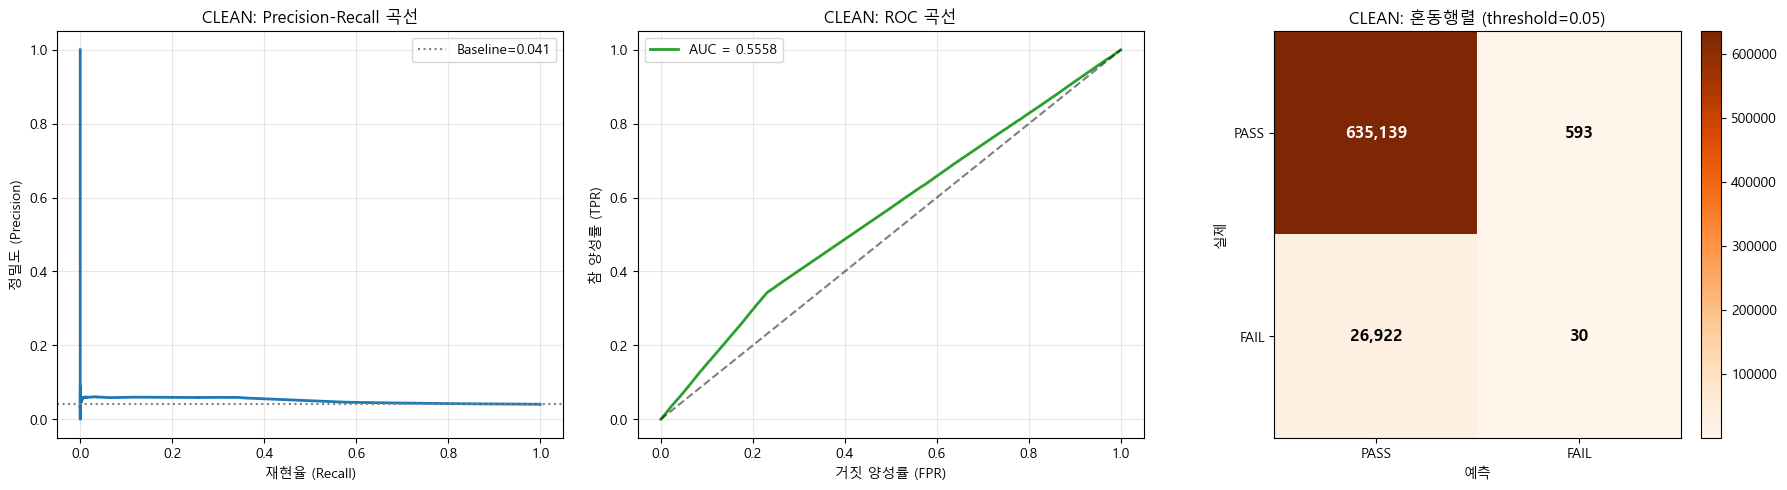


[CLEAN] 혼동행렬:
[[635139    593]
 [ 26922     30]]
TN=635,139  FP=593
FN=26,922  TP=30


In [26]:
# 7-3. CLEAN 모델 PR / ROC / Confusion Matrix
prec_arr_c, rec_arr_c, _ = precision_recall_curve(y_test_final, y_pred_proba_c)
fpr_c, tpr_c, _ = roc_curve(y_test_final, y_pred_proba_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rec_arr_c, prec_arr_c, color='tab:blue', linewidth=2)
axes[0].axhline(y_test_final.mean(), color='gray', linestyle=':',
                label=f'Baseline={y_test_final.mean():.3f}')
axes[0].set_xlabel('재현율 (Recall)')
axes[0].set_ylabel('정밀도 (Precision)')
axes[0].set_title('CLEAN: Precision-Recall 곡선')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(fpr_c, tpr_c, color='tab:green', linewidth=2, label=f'AUC = {auc_roc_c:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('거짓 양성률 (FPR)')
axes[1].set_ylabel('참 양성률 (TPR)')
axes[1].set_title('CLEAN: ROC 곡선')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

cm_c = confusion_matrix(y_test_final, y_pred_best_c)
im = axes[2].imshow(cm_c, cmap='Oranges')
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['PASS', 'FAIL'])
axes[2].set_yticklabels(['PASS', 'FAIL'])
axes[2].set_xlabel('예측'); axes[2].set_ylabel('실제')
axes[2].set_title(f'CLEAN: 혼동행렬 (threshold={best_th_c:.2f})')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm_c[i,j]:,}', ha='center', va='center',
                     color='white' if cm_c[i,j] > cm_c.max()/2 else 'black',
                     fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f'\n[CLEAN] 혼동행렬:\n{cm_c}')
print(f'TN={cm_c[0,0]:,}  FP={cm_c[0,1]:,}')
print(f'FN={cm_c[1,0]:,}  TP={cm_c[1,1]:,}')


CLEAN SHAP 계산: 0.1s, shape=(20000, 16)


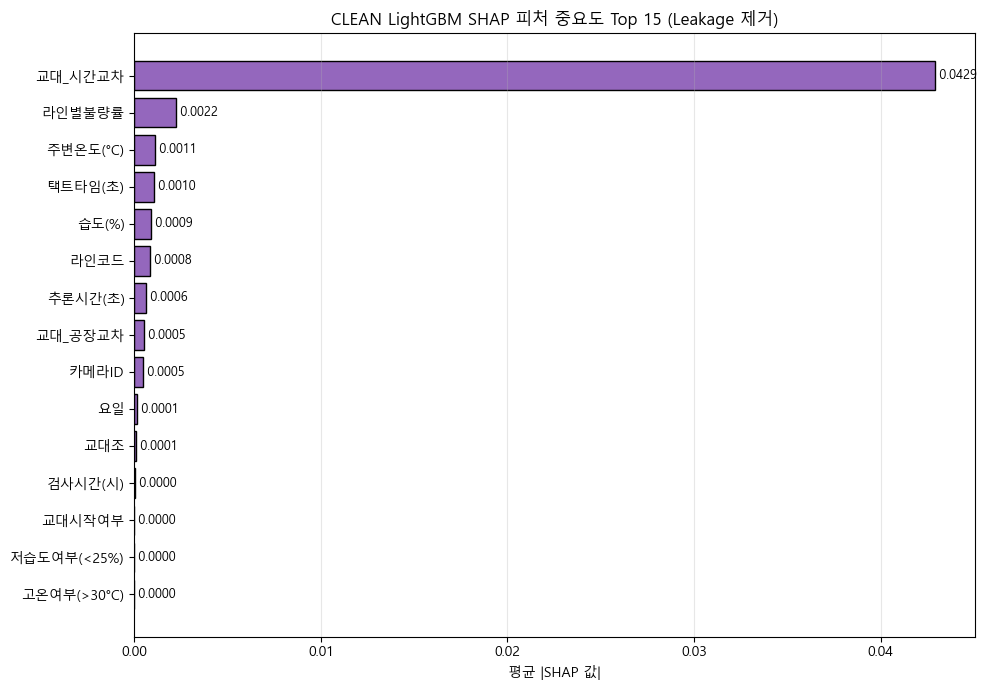


[CLEAN Top 10 피처 중요도]
feature_kor  mean_abs_shap
    교대_시간교차       0.042910
     라인별불량률       0.002218
   주변온도(°C)       0.001113
    택트타임(초)       0.001035
      습도(%)       0.000924
       라인코드       0.000842
    추론시간(초)       0.000610
    교대_공장교차       0.000512
      카메라ID       0.000470
         요일       0.000130


In [27]:
# 7-4. CLEAN 모델 SHAP 피처 중요도
X_shap_c = X_test_c.iloc[sample_idx].reset_index(drop=True)

explainer_c = shap.TreeExplainer(model_clean)
t0 = time.time()
shap_values_c = explainer_c.shap_values(X_shap_c)
if isinstance(shap_values_c, list):
    shap_values_c = shap_values_c[1]
print(f'CLEAN SHAP 계산: {time.time()-t0:.1f}s, shape={shap_values_c.shape}')

mean_abs_c = np.abs(shap_values_c).mean(axis=0)
imp_df_c = pd.DataFrame({
    'feature': X_shap_c.columns,
    'feature_kor': [FEATURE_KOR.get(c, c) for c in X_shap_c.columns],
    'mean_abs_shap': mean_abs_c,
}).sort_values('mean_abs_shap', ascending=True)

top15_c = imp_df_c.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15_c['feature_kor'], top15_c['mean_abs_shap'],
               color='tab:purple', edgecolor='black')
ax.set_xlabel('평균 |SHAP 값|')
ax.set_title('CLEAN LightGBM SHAP 피처 중요도 Top 15 (Leakage 제거)')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, top15_c['mean_abs_shap']):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n[CLEAN Top 10 피처 중요도]')
print(imp_df_c.sort_values('mean_abs_shap', ascending=False)
             .head(10)[['feature_kor', 'mean_abs_shap']].to_string(index=False))


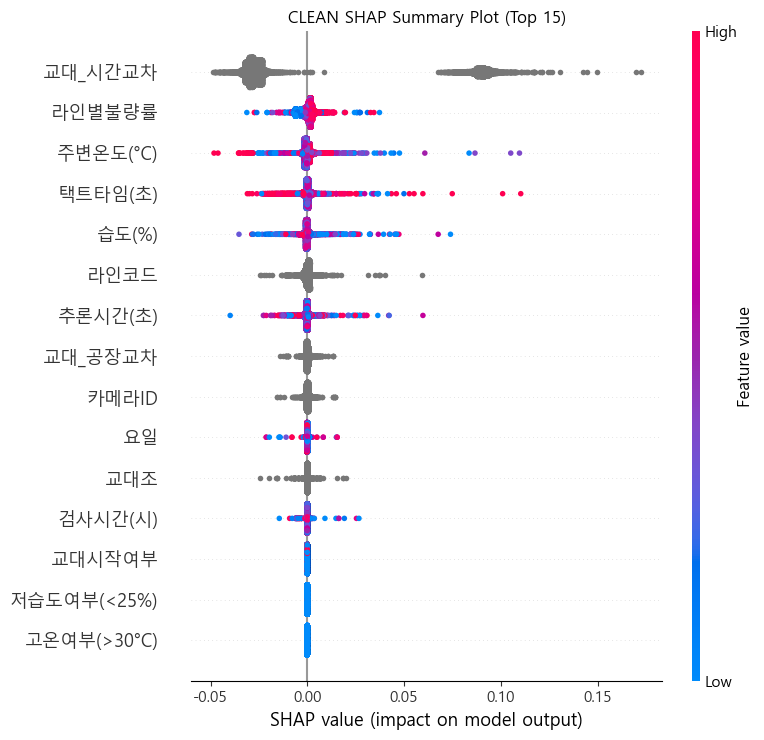


CLEAN 피처 수: 16

[교대조 효과 (shift / shift_hour)]
  shift                 rank=11/16  |SHAP|=0.0001
  shift_hour            rank= 1/16  |SHAP|=0.0429
  shift_plant           rank= 8/16  |SHAP|=0.0005
  => 상위 5 안 진입: 확인 (best=shift_hour, rank=1)

[교대 시작 시간대 (is_shift_start / hour)]
  is_shift_start        rank=16/16  |SHAP|=0.0000
  hour                  rank=12/16  |SHAP|=0.0000
  shift_hour            rank= 1/16  |SHAP|=0.0429
  => 상위 5 안 진입: 확인 (best=shift_hour, rank=1)

[저습도 구간 (low_humidity / humidity_pct)]
  low_humidity          rank=15/16  |SHAP|=0.0000
  humidity_pct          rank= 5/16  |SHAP|=0.0009
  => 상위 5 안 진입: 확인 (best=humidity_pct, rank=5)


In [28]:
# 7-5. CLEAN 모델 SHAP Summary plot + EDA 인사이트 검증
X_shap_c_kor = X_shap_c.copy()
X_shap_c_kor.columns = [FEATURE_KOR.get(c, c) for c in X_shap_c.columns]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_c, X_shap_c_kor, plot_type='dot', show=False, max_display=15)
plt.title('CLEAN SHAP Summary Plot (Top 15)')
plt.tight_layout()
plt.show()

# EDA 인사이트 재검증
rank_map_c = {f: r for r, f in enumerate(
    imp_df_c.sort_values('mean_abs_shap', ascending=False)['feature'].tolist(), 1)}
imp_map_c = dict(zip(imp_df_c['feature'], imp_df_c['mean_abs_shap']))
N_CLEAN = len(imp_df_c)

print(f'\nCLEAN 피처 수: {N_CLEAN}')
print('=' * 60)
insight_verified_clean = {}
for label, feats in targets.items():
    print(f'\n[{label}]')
    best_rank, best_feat = N_CLEAN + 1, None
    for f in feats:
        if f in rank_map_c:
            r = rank_map_c[f]
            val = imp_map_c[f]
            print(f'  {f:20s}  rank={r:>2d}/{N_CLEAN}  |SHAP|={val:.4f}')
            if r < best_rank:
                best_rank, best_feat = r, f
    verified = best_rank <= 5
    insight_verified_clean[label] = {
        'best_rank_in_top': int(best_rank),
        'verified_top5':    bool(verified),
    }
    print(f'  => 상위 5 안 진입: {"확인" if verified else "불확인"} '
          f'(best={best_feat}, rank={best_rank})')


---
## 결론 요약

노트북 실행 후 CLAUDE.md 에 최종 결과를 아래 항목으로 기록한다.

1. Train/Test 기간 및 FAIL 비율
2. 최적 threshold 에서의 Precision / Recall / F1 / AUC-ROC
3. SHAP Top 5 피처 (한글)
4. EDA 인사이트 검증 결과 (C조 · 저습도 · 교대시작)
5. 모델링 결론 (실운영 가능 여부, leakage 피처 제외 관점의 실질 성능)


In [29]:
# 최종 결과를 JSON 으로 저장 (CLAUDE.md 업데이트용) — 두 모델 모두
result = {
    'train_period':    f'{df_train["inspection_datetime"].min().date()} ~ {df_train["inspection_datetime"].max().date()}',
    'test_period':     f'{df_test["inspection_datetime"].min().date()} ~ {df_test["inspection_datetime"].max().date()}',
    'train_rows':      int(len(df_train)),
    'test_rows_full':  int(len(df_test)),
    'test_rows_final': int(len(X_test_final)),
    'train_fail_pct':  round(float(df_train['target'].mean() * 100), 3),
    'test_fail_pct':   round(float(df_test['target'].mean() * 100), 3),
    # 1차 모델: 전체 피처 (defect_detail 집계 피처 포함 → LEAKAGE)
    'model_full': {
        'best_threshold': round(float(best_th), 2),
        'precision':      round(float(final_prec), 4),
        'recall':         round(float(final_rec), 4),
        'f1':             round(float(final_f1), 4),
        'auc_roc':        round(float(auc_roc), 4),
        'best_iteration': int(model.best_iteration),
        'top_features': (
            imp_df.sort_values('mean_abs_shap', ascending=False)
                  .head(5)[['feature', 'feature_kor', 'mean_abs_shap']]
                  .assign(mean_abs_shap=lambda d: d['mean_abs_shap'].round(4))
                  .to_dict(orient='records')
        ),
    },
    # 2차 모델: CLEAN 피처 (leakage 5종 제거)
    'model_clean': {
        'features_excluded': sorted(LEAKAGE_FEATURES),
        'best_threshold': round(float(best_th_c), 2),
        'precision':      round(float(final_prec_c), 4),
        'recall':         round(float(final_rec_c), 4),
        'f1':             round(float(final_f1_c), 4),
        'auc_roc':        round(float(auc_roc_c), 4),
        'best_iteration': int(model_clean.best_iteration),
        'top_features': (
            imp_df_c.sort_values('mean_abs_shap', ascending=False)
                    .head(5)[['feature', 'feature_kor', 'mean_abs_shap']]
                    .assign(mean_abs_shap=lambda d: d['mean_abs_shap'].round(4))
                    .to_dict(orient='records')
        ),
        'eda_insight_verification': insight_verified_clean,
    },
}

# 1차 모델 EDA 검증도 기록
insight_verified_full = {}
for label, feats in targets.items():
    best_rank = min((rank_map.get(f, N_FEAT+1) for f in feats), default=N_FEAT+1)
    insight_verified_full[label] = {
        'best_rank_in_top': int(best_rank),
        'verified_top10':   bool(best_rank <= 10),
    }
result['model_full']['eda_insight_verification'] = insight_verified_full

with open(r'c:/Users/user/Desktop/PROJ2/_lgbm_result.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2, default=str)

print('최종 결과 저장: _lgbm_result.json')
print(json.dumps(result, ensure_ascii=False, indent=2, default=str))


최종 결과 저장: _lgbm_result.json
{
  "train_period": "2023-01-01 ~ 2024-06-30",
  "test_period": "2024-07-01 ~ 2025-01-24",
  "train_rows": 2171646,
  "test_rows_full": 828354,
  "test_rows_final": 662684,
  "train_fail_pct": 4.071,
  "test_fail_pct": 4.067,
  "model_full": {
    "best_threshold": 0.05,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "auc_roc": 1.0,
    "best_iteration": 1,
    "top_features": [
      {
        "feature": "defect_count",
        "feature_kor": "결함수",
        "mean_abs_shap": 0.0996
      },
      {
        "feature": "ambient_temp_c",
        "feature_kor": "주변온도(°C)",
        "mean_abs_shap": 0.0
      },
      {
        "feature": "humidity_pct",
        "feature_kor": "습도(%)",
        "mean_abs_shap": 0.0
      },
      {
        "feature": "plant_code",
        "feature_kor": "공장코드",
        "mean_abs_shap": 0.0
      },
      {
        "feature": "shift",
        "feature_kor": "교대조",
        "mean_abs_shap": 0.0
      }
    ],
    "eda_ins